# Explainable Sentinel-1 SAR Flood Mapping with Physically Informed ML and HAND
### Reproducible pipeline (Sen1Floods11 + MERIT HAND + Bangladesh case study)




## 0. Environment

In [1]:
import sys
try:
    import numpy as np, pandas as pd, rasterio
    from scipy.ndimage import uniform_filter, label as cc_label
    from rasterio.warp import reproject, Resampling, transform_bounds
    from rasterio.windows import Window
    import sklearn
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import GroupKFold
    from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                                 recall_score, confusion_matrix)
    import xgboost as xgb
    import shap, joblib
    import matplotlib.pyplot as plt
except Exception as e:
    raise SystemExit(
        f"Import failed: {e}\n\nFrom an Anaconda Prompt (not inside Jupyter), then restart the kernel:\n"
        '  conda install "numpy=1.26.4" pandas rasterio scikit-learn xgboost shap scipy matplotlib joblib -c conda-forge -y')
print("numpy", np.__version__, "| sklearn", sklearn.__version__, "| xgboost", xgb.__version__,
      "| shap", shap.__version__, "| rasterio", rasterio.__version__)

e:\Anaconda3\envs\flood\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


numpy 1.26.4 | sklearn 1.9.1 | xgboost 3.2.0 | shap 0.48.0 | rasterio 1.4.4


## 1. Configuration
Set `DATA_ROOT` to the folder that contains `data/flood_events/HandLabeled/` and `splits/`.
Outputs and cache are written to a relative `outputs/` folder for portability.

In [2]:
from pathlib import Path

# ---- the only path you must set ----
DATA_ROOT = Path(r"E:\GRIET\files\sen1floods11\v1.1")     # <-- EDIT THIS
# Optional Bangladesh scenes (case study is skipped if these are missing):
BD_S1_FLOOD = Path(r"E:\GRIET\files\bangladesh\BD_S1_flood.tif")
BD_S1_DRY   = Path(r"E:\GRIET\files\bangladesh\BD_S1_dry.tif")
BD_HAND     = Path(r"E:\GRIET\files\bangladesh\BD_HAND.tif")
# ------------------------------------

HAND_DIR = DATA_ROOT / "hand"                              # per-region HAND_*.tif (from GEE)
HAND_LAND = DATA_ROOT / "data" / "flood_events" / "HandLabeled"
S1_DIR    = HAND_LAND / "S1Hand"
LABEL_DIR = HAND_LAND / "LabelHand"
SPLIT_DIR = DATA_ROOT / "splits"

OUT_DIR = Path("outputs"); OUT_DIR.mkdir(exist_ok=True)
CACHE   = OUT_DIR / "cache"; CACHE.mkdir(exist_ok=True)

VV_CLIP, VH_CLIP = (-23.0, 0.0), (-28.0, 0.0)
TEXTURE_WIN = 5
PIXELS_PER_CHIP = 3000
WATER_FRAC = 0.5
RANDOM_STATE = 42

FEATURE_NAMES = ["VV","VH","VV_minus_VH","NDPI","VV_std5","VH_std5",
                 "VV_mean11","VH_mean11","VV_mean21","VH_mean21","VV_rel21","VH_rel21","HAND"]

# reproduction flags (see runtime note at top)
RUN_ABLATION   = False
RUN_FRAC_SWEEP = False

rng = np.random.default_rng(RANDOM_STATE)
for p in (S1_DIR, LABEL_DIR, SPLIT_DIR):
    print(("OK   " if p.exists() else "MISSING ") + str(p))
print("HAND per-region dir:", "OK" if HAND_DIR.exists() else "MISSING (HAND feature will be imputed)")

OK   E:\GRIET\files\sen1floods11\v1.1\data\flood_events\HandLabeled\S1Hand
OK   E:\GRIET\files\sen1floods11\v1.1\data\flood_events\HandLabeled\LabelHand
OK   E:\GRIET\files\sen1floods11\v1.1\splits
HAND per-region dir: OK


## 2. Chip index and official geographic splits

In [3]:
import re
def chip_stem(fn): return re.sub(r"_(S1Hand|LabelHand)\.tif$", "", Path(fn).name)

present = {}
for f in S1_DIR.glob("*_S1Hand.tif"):
    lab = LABEL_DIR / f"{chip_stem(f.name)}_LabelHand.tif"
    if lab.exists(): present[chip_stem(f.name)] = (f, lab)
print(f"{len(present)} S1/Label chip pairs found")

def read_split_csv(path):
    stems=set()
    for line in Path(path).read_text().splitlines():
        for tok in re.split(r"[,\s]+", line.strip()):
            m=re.search(r"([A-Za-z\-]+_\d+)", tok)
            if m: stems.add(m.group(1))
    return stems

split_files={}
for csv in SPLIT_DIR.rglob("*.csv"):
    n=csv.name.lower()
    if "train" in n: split_files.setdefault("train",[]).append(csv)
    elif "val" in n: split_files.setdefault("val",[]).append(csv)
    elif "test" in n: split_files.setdefault("test",[]).append(csv)

splits={}
for k in ("train","val","test"):
    s=set()
    for csv in split_files.get(k,[]): s|=read_split_csv(csv)
    splits[k]=sorted(s & set(present))
for k in ("train","val","test"): print(f"{k:5s}: {len(splits[k])} chips")
if not splits["train"] or not splits["test"]:
    raise SystemExit("Could not parse splits/. Inspect CSVs in SPLIT_DIR and adjust read_split_csv().")

446 S1/Label chip pairs found
train: 252 chips
val  : 89 chips
test : 90 chips


## 3. Feature extraction (13 features)

Exact definitions used below (these match the manuscript):

- **Lee speckle filter** — adaptive, NaN-aware, applied independently to VV and VH on the **dB** arrays with a **5×5** window: `out = mean + k*(x - mean)`, `k = var / (var + overall_var)`.
- **VV, VH** — Lee-filtered backscatter (dB).
- **VV_minus_VH** — `VV_f − VH_f` (dB log-ratio).
- **NDPI** — computed in **linear power**: `NDPI = (VV_lin − VH_lin)/(VV_lin + VH_lin)`, `X_lin = 10^(X_f/10)`.
- **VV_std5, VH_std5** — 5×5 local standard deviation on the **unfiltered** bands (roughness).
- **VV_mean11, VH_mean11 / VV_mean21, VH_mean21** — neighbourhood means of the filtered bands at 11×11 and 21×21.
- **VV_rel21, VH_rel21** — pixel minus its 21×21 background: `VV_f − VV_mean21` (a difference, not a ratio).
- **HAND** — MERIT Hydro height above nearest drainage, bilinearly resampled to the 10 m grid (an interpolated topographic prior; ocean/undefined masked). Missing HAND is median-imputed so RandomForest is unaffected; HAND never invalidates a pixel.


In [4]:
def nan_uniform_mean_std(arr, size):
    mask = np.isfinite(arr).astype(np.float32)
    filled = np.where(np.isfinite(arr), arr, 0.0).astype(np.float32)
    s1 = uniform_filter(filled, size=size, mode="reflect")
    s2 = uniform_filter(filled*filled, size=size, mode="reflect")
    c  = uniform_filter(mask, size=size, mode="reflect")
    with np.errstate(invalid="ignore", divide="ignore"):
        mean = np.where(c>0, s1/c, np.nan)
        var  = np.clip(np.where(c>0, s2/c - mean**2, np.nan), 0, None)
    return mean, np.sqrt(var)

def lee_filter(arr, size=5):
    mean, std = nan_uniform_mean_std(arr, size)
    var = std**2
    finite = arr[np.isfinite(arr)]
    overall = np.var(finite) if finite.size else 0.0
    with np.errstate(invalid="ignore", divide="ignore"):
        k = var/(var+overall)
    out = mean + k*(arr-mean)
    return np.where(np.isfinite(arr), out, np.nan)

# per-region HAND lookup for benchmark chips
hand_files = {}
if HAND_DIR.exists():
    hand_files = {f.stem.replace("HAND_",""): f for f in HAND_DIR.glob("HAND_*.tif")}
def _region(path): return chip_stem(path).rsplit("_",1)[0]

def hand_on_grid(ref_path):
    reg=_region(ref_path)
    if reg not in hand_files: return None
    with rasterio.open(ref_path) as ref:
        t,crs,H,W = ref.transform, ref.crs, ref.height, ref.width
    dst=np.full((H,W), np.nan, np.float32)
    with rasterio.open(hand_files[reg]) as src:
        reproject(source=rasterio.band(src,1), destination=dst,
                  src_transform=src.transform, src_crs=src.crs,
                  dst_transform=t, dst_crs=crs, resampling=Resampling.bilinear)
    return np.where(dst<=-9990, np.nan, dst)

def read_chip(s1_path, label_path):
    with rasterio.open(s1_path) as src:
        arr=src.read(masked=True).astype(np.float32)
    vv=np.ma.filled(arr[0],np.nan); vh=np.ma.filled(arr[1],np.nan)
    vv=np.where((vv==0)|~np.isfinite(vv), np.nan, np.clip(vv,*VV_CLIP))
    vh=np.where((vh==0)|~np.isfinite(vh), np.nan, np.clip(vh,*VH_CLIP))
    with rasterio.open(label_path) as src:
        label=src.read(1).astype(np.int16)
    return vv, vh, label, hand_on_grid(s1_path)

def build_features(vv, vh, hand=None):
    vv_f=lee_filter(vv,TEXTURE_WIN); vh_f=lee_filter(vh,TEXTURE_WIN)
    vv_lin=10.0**(vv_f/10.0); vh_lin=10.0**(vh_f/10.0)
    denom=vv_lin+vh_lin
    ndpi=np.where(denom>0,(vv_lin-vh_lin)/denom,np.nan)
    _,vv_s5=nan_uniform_mean_std(vv,5); _,vh_s5=nan_uniform_mean_std(vh,5)
    vv_m11,_=nan_uniform_mean_std(vv_f,11); vh_m11,_=nan_uniform_mean_std(vh_f,11)
    vv_m21,_=nan_uniform_mean_std(vv_f,21); vh_m21,_=nan_uniform_mean_std(vh_f,21)
    if hand is None: hand=np.full(vv.shape,np.nan,np.float32)
    hand = np.where(np.isfinite(hand),hand,np.nanmedian(hand)) if np.isfinite(hand).any() else np.zeros_like(vv)
    stack={"VV":vv_f,"VH":vh_f,"VV_minus_VH":vv_f-vh_f,"NDPI":ndpi,
           "VV_std5":vv_s5,"VH_std5":vh_s5,"VV_mean11":vv_m11,"VH_mean11":vh_m11,
           "VV_mean21":vv_m21,"VH_mean21":vh_m21,"VV_rel21":vv_f-vv_m21,"VH_rel21":vh_f-vh_m21,"HAND":hand}
    return np.stack([stack[k] for k in FEATURE_NAMES],axis=-1)

def valid_mask(X, label):
    return np.isfinite(X[...,:-1]).all(axis=-1) & (label!=-1)   # HAND excluded (imputed)
print("feature functions ready:", len(FEATURE_NAMES), "features")

feature functions ready: 13 features


### 3b. Logic self-test (no data required)

In [5]:
def water_iou(yt, yp):
    inter=np.sum((yt==1)&(yp==1)); union=np.sum((yt==1)|(yp==1))
    return inter/union if union>0 else np.nan
_vv=np.full((8,8),-8.0); _vv[4:,:4]=-20.0
_vh=np.full((8,8),-14.0); _vh[4:,:4]=-26.0
_X=build_features(_vv,_vh)
assert _X.shape==(8,8,len(FEATURE_NAMES))
_yt=np.zeros((8,8),int); _yt[4:,:4]=1
assert abs(water_iou(_yt,_yt)-1.0)<1e-9
print("self-test passed")

self-test passed


## 4. Training matrix (chip-grouped, balanced per chip; cached)

`WATER_FRAC = 0.5` means each chip contributes up to `PIXELS_PER_CHIP` samples drawn to be ~50% water / 50% non-water (balanced per-chip sampling), not 50% of all water pixels.

In [6]:
def sample_chip(stem, s1, lab, frac=WATER_FRAC):
    vv,vh,label,hand=read_chip(s1,lab)
    X=build_features(vv,vh,hand); v=valid_mask(X,label); y=label
    water=np.argwhere(v&(y==1)); dry=np.argwhere(v&(y==0))
    if len(water)==0 or len(dry)==0:
        pool=water if len(water) else dry
        if len(pool)==0: return None
        take=pool[rng.choice(len(pool),min(len(pool),PIXELS_PER_CHIP),replace=False)]
    else:
        nw=int(PIXELS_PER_CHIP*frac); nd=PIXELS_PER_CHIP-nw
        wi=water[rng.choice(len(water),min(len(water),nw),replace=False)]
        di=dry[rng.choice(len(dry),min(len(dry),nd),replace=False)]
        take=np.vstack([wi,di])
    r,c=take[:,0],take[:,1]
    return X[r,c,:], y[r,c].astype(int), np.full(len(take),stem)

tr_cache=CACHE/"train_matrix.npz"
if tr_cache.exists():
    d=np.load(tr_cache, allow_pickle=True)
    X_train,y_train,groups=d["X"],d["y"],d["g"]
    print("loaded cached training matrix")
else:
    rng=np.random.default_rng(RANDOM_STATE)
    Xs,ys,gs=[],[],[]
    for i,stem in enumerate(splits["train"],1):
        r=sample_chip(stem,*present[stem])
        if r is not None: Xs.append(r[0]);ys.append(r[1]);gs.append(r[2])
        if i%50==0: print(f"  {i}/{len(splits['train'])}")
    X_train=np.vstack(Xs); y_train=np.concatenate(ys); groups=np.concatenate(gs)
    np.savez_compressed(tr_cache, X=X_train, y=y_train, g=groups)
print("training matrix:", X_train.shape, "| water frac", round(float(y_train.mean()),3))

  50/252
  100/252
  150/252
  200/252
  250/252
training matrix: (710693, 13) | water frac 0.404


## 5. Models and chip-grouped cross-validation (training data only)

Final configuration uses no additional class re-weighting (balanced sampling already handles imbalance). CV is 5-fold GroupKFold on the 252 training chips; the validation/test splits are not involved.

In [7]:
def make_models():
    xgb_clf=xgb.XGBClassifier(n_estimators=400,max_depth=6,learning_rate=0.08,
        subsample=0.8,colsample_bytree=0.8,tree_method="hist",eval_metric="logloss",
        base_score=0.5,n_jobs=-1,random_state=RANDOM_STATE)
    rf_clf=RandomForestClassifier(n_estimators=300,min_samples_leaf=5,n_jobs=-1,random_state=RANDOM_STATE)
    return xgb_clf,rf_clf

gkf=GroupKFold(n_splits=5); cv=[]
for fold,(tr,va) in enumerate(gkf.split(X_train,y_train,groups),1):
    xc,rc=make_models(); xc.fit(X_train[tr],y_train[tr]); rc.fit(X_train[tr],y_train[tr])
    p=0.5*xc.predict_proba(X_train[va])[:,1]+0.5*rc.predict_proba(X_train[va])[:,1]
    f=f1_score(y_train[va],(p>=0.5).astype(int),zero_division=0); cv.append(f)
    print(f"fold {fold}: F1(water)={f:.3f}")
print(f"\nCV mean F1(water) = {np.mean(cv):.3f} +/- {np.std(cv):.3f}")

fold 1: F1(water)=0.835
fold 2: F1(water)=0.789
fold 3: F1(water)=0.818
fold 4: F1(water)=0.834
fold 5: F1(water)=0.771

CV mean F1(water) = 0.810 +/- 0.025


## 6. Final fit (retrain on all training chips; cached)

In [8]:
mdl_cache=CACHE/"final_models.joblib"
if mdl_cache.exists():
    o=joblib.load(mdl_cache); xgb_final,rf_final=o["xgb"],o["rf"]; print("loaded cached models")
else:
    xgb_final,rf_final=make_models(); xgb_final.fit(X_train,y_train); rf_final.fit(X_train,y_train)
    joblib.dump({"xgb":xgb_final,"rf":rf_final,"features":FEATURE_NAMES}, mdl_cache)
    print("fitted final ensemble")
def predict_proba(X2d):
    return 0.5*xgb_final.predict_proba(X2d)[:,1]+0.5*rf_final.predict_proba(X2d)[:,1]

fitted final ensemble


## 7. Validation-only calibration (threshold + blob size)

In [9]:
def clean_mask(binary, min_size):
    if min_size<=0: return binary
    lab,n=cc_label(binary)
    if n==0: return binary
    sizes=np.bincount(lab.ravel()); small=np.where(sizes<min_size)[0]; small=small[small!=0]
    if small.size: binary=binary.copy(); binary[np.isin(lab,small)]=0
    return binary

def chip_prob(stem):
    vv,vh,label,hand=read_chip(*present[stem]); X=build_features(vv,vh,hand); v=valid_mask(X,label)
    prob=np.full(label.shape,np.nan)
    if v.sum()>0: prob[v]=predict_proba(X[v])
    return prob,label,v

def mean_val_iou(cache,thr,ms):
    ious=[]
    for prob,label,v in cache:
        pred=clean_mask(((prob>=thr)&v).astype(np.uint8),ms).astype(bool)
        yt=(label==1)&v; inter=np.sum(yt&pred); union=np.sum(yt|pred)
        if union>0: ious.append(inter/union)
    return np.nanmean(ious)

print("caching validation probability maps...")
val_cache=[chip_prob(s) for s in splits["val"]]
best=None
for thr in np.round(np.arange(0.50,0.96,0.05),2):
    for ms in [0,10,25,50,100]:
        m=mean_val_iou(val_cache,thr,ms)
        if best is None or m>best[0]: best=(m,thr,ms)
BEST_IOU,BEST_THR,BEST_MS=best
print(f"selected on VAL: threshold={BEST_THR}, blob={BEST_MS}, val mean IoU={BEST_IOU:.3f}")

caching validation probability maps...
selected on VAL: threshold=0.7, blob=100, val mean IoU=0.396


## 8. Test evaluation — metrics, confusion matrix, image-wise IoU distribution

=== TEST RESULTS ===
  n_test_chips            : 85
  mean_image_IoU_water    : 0.3952
  median_image_IoU_water  : 0.3793
  std_image_IoU_water     : 0.2959
  pixel_F1_water          : 0.7872
  pixel_precision_water   : 0.8059
  pixel_recall_water      : 0.7693
  pixel_overall_accuracy  : 0.9488
  TP                      : 1934875
  FP                      : 466097
  TN                      : 17462854
  FN                      : 580133
  threshold               : 0.7
  min_blob                : 100

Confusion matrix (pixels):
                  pred non-water  pred water
actual non-water        17462854      466097
actual water              580133     1934875


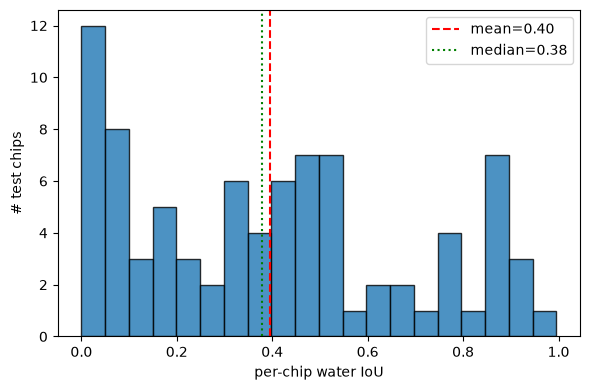

In [10]:
per_iou=[]; yt_all=[]; yp_all=[]
for i,stem in enumerate(splits["test"],1):
    prob,label,v=chip_prob(stem)
    if v.sum()==0: continue
    pred=clean_mask(((prob>=BEST_THR)&v).astype(np.uint8),BEST_MS).astype(bool)
    yt=(label==1)&v; inter=np.sum(yt&pred); union=np.sum(yt|pred)
    if union>0: per_iou.append(inter/union)
    yt_all.append(label[v].astype(int)); yp_all.append(pred[v].astype(int))
yt_all=np.concatenate(yt_all); yp_all=np.concatenate(yp_all); per_iou=np.array(per_iou)

tn,fp,fn,tp=confusion_matrix(yt_all,yp_all,labels=[0,1]).ravel()
metrics={
 "n_test_chips":int(len(per_iou)),
 "mean_image_IoU_water":round(float(np.nanmean(per_iou)),4),
 "median_image_IoU_water":round(float(np.nanmedian(per_iou)),4),
 "std_image_IoU_water":round(float(np.nanstd(per_iou)),4),
 "pixel_F1_water":round(f1_score(yt_all,yp_all,zero_division=0),4),
 "pixel_precision_water":round(precision_score(yt_all,yp_all,zero_division=0),4),
 "pixel_recall_water":round(recall_score(yt_all,yp_all,zero_division=0),4),
 "pixel_overall_accuracy":round(accuracy_score(yt_all,yp_all),4),
 "TP":int(tp),"FP":int(fp),"TN":int(tn),"FN":int(fn),
 "threshold":float(BEST_THR),"min_blob":int(BEST_MS)}
print("=== TEST RESULTS ===")
for k,val in metrics.items(): print(f"  {k:24s}: {val}")
pd.DataFrame([metrics]).to_csv(OUT_DIR/"test_metrics.csv",index=False)

print("\nConfusion matrix (pixels):")
print(pd.DataFrame([[tn,fp],[fn,tp]],
      index=["actual non-water","actual water"], columns=["pred non-water","pred water"]))

plt.figure(figsize=(6,4))
plt.hist(per_iou,bins=20,edgecolor="k",alpha=0.8)
plt.axvline(np.nanmean(per_iou),color="r",ls="--",label=f"mean={np.nanmean(per_iou):.2f}")
plt.axvline(np.nanmedian(per_iou),color="g",ls=":",label=f"median={np.nanmedian(per_iou):.2f}")
plt.xlabel("per-chip water IoU"); plt.ylabel("# test chips"); plt.legend(); plt.tight_layout()
plt.savefig(OUT_DIR/"iou_distribution.png",dpi=200); plt.show()

## 9. SHAP interpretation (TreeSHAP via XGBoost pred_contribs)

SHAP ranking (mean |contribution|):
  HAND          : 0.6820
  VH            : 0.6766
  VH_mean11     : 0.6303
  VH_std5       : 0.3100
  VV_std5       : 0.3046
  VH_mean21     : 0.1570
  VV_rel21      : 0.1303
  VV_mean21     : 0.1120
  VV            : 0.0974
  VH_rel21      : 0.0851
  VV_mean11     : 0.0420
  VV_minus_VH   : 0.0347
  NDPI          : 0.0062


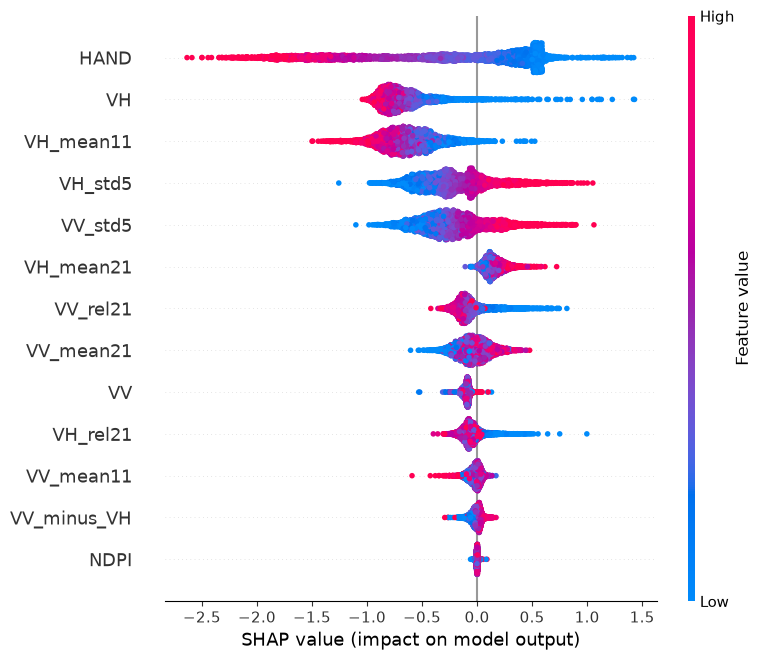

In [11]:
shap_X,need=[],5000
for stem in splits["test"]:
    vv,vh,label,hand=read_chip(*present[stem]); X=build_features(vv,vh,hand); v=valid_mask(X,label)
    vv2=X[v]; take=min(len(vv2),need-sum(len(s) for s in shap_X))
    shap_X.append(vv2[rng.choice(len(vv2),take,replace=False)])
    if sum(len(s) for s in shap_X)>=need: break
shap_X=np.vstack(shap_X).astype(np.float32)
booster=xgb_final.get_booster()
contribs=booster.predict(xgb.DMatrix(shap_X,feature_names=FEATURE_NAMES),pred_contribs=True)[:,:-1]
order=np.argsort(np.abs(contribs).mean(0))[::-1]
print("SHAP ranking (mean |contribution|):")
for i in order: print(f"  {FEATURE_NAMES[i]:14s}: {np.abs(contribs).mean(0)[i]:.4f}")
plt.figure(); shap.summary_plot(contribs,shap_X,feature_names=FEATURE_NAMES,show=False)
plt.tight_layout(); plt.savefig(OUT_DIR/"shap_summary_final.png",dpi=200,bbox_inches="tight"); plt.show()

## 10. Ablation (optional — set `RUN_ABLATION=True`)

Systematically toggles pipeline components from the final codebase. Note: these are computed from the unified final code, so if a value differs slightly from the manuscript's Table 3, update the manuscript to match this notebook's output (the notebook is the source of truth).

In [12]:
def build_features_cfg(vv,vh,hand,use_lee,use_context,use_hand):
    base = lee_filter(vv,TEXTURE_WIN) if use_lee else vv
    baseh= lee_filter(vh,TEXTURE_WIN) if use_lee else vh
    vv_lin=10.0**(base/10.0); vh_lin=10.0**(baseh/10.0); denom=vv_lin+vh_lin
    feats={"VV":base,"VH":baseh,"VV_minus_VH":base-baseh,
           "NDPI":np.where(denom>0,(vv_lin-vh_lin)/denom,np.nan)}
    _,s5=nan_uniform_mean_std(vv,5); _,s5h=nan_uniform_mean_std(vh,5)
    feats["VV_std5"]=s5; feats["VH_std5"]=s5h
    if use_context:
        m11,_=nan_uniform_mean_std(base,11); m11h,_=nan_uniform_mean_std(baseh,11)
        m21,_=nan_uniform_mean_std(base,21); m21h,_=nan_uniform_mean_std(baseh,21)
        feats.update({"VV_mean11":m11,"VH_mean11":m11h,"VV_mean21":m21,"VH_mean21":m21h,
                      "VV_rel21":base-m21,"VH_rel21":baseh-m21h})
    if use_hand:
        if hand is None: hand=np.full(vv.shape,np.nan,np.float32)
        hand=np.where(np.isfinite(hand),hand,np.nanmedian(hand)) if np.isfinite(hand).any() else np.zeros_like(vv)
        feats["HAND"]=hand
    names=list(feats.keys())
    return np.stack([feats[k] for k in names],axis=-1), names

def run_config(use_lee,use_context,use_hand,tune):
    rloc=np.random.default_rng(RANDOM_STATE)
    Xs,ys=[],[]
    for stem in splits["train"]:
        vv,vh,label,hand=read_chip(*present[stem]); X,_=build_features_cfg(vv,vh,hand,use_lee,use_context,use_hand)
        vmask=np.isfinite(X).all(-1)&(label!=-1); y=label
        w=np.argwhere(vmask&(y==1)); d=np.argwhere(vmask&(y==0))
        if len(w)==0 or len(d)==0: continue
        nw=int(PIXELS_PER_CHIP*0.5)
        wi=w[rloc.choice(len(w),min(len(w),nw),replace=False)]; di=d[rloc.choice(len(d),min(len(d),PIXELS_PER_CHIP-nw),replace=False)]
        t=np.vstack([wi,di]); Xs.append(X[t[:,0],t[:,1],:]); ys.append(y[t[:,0],t[:,1]].astype(int))
    Xtr=np.vstack(Xs); ytr=np.concatenate(ys)
    xc,rc=make_models(); xc.fit(Xtr,ytr); rc.fit(Xtr,ytr)
    def pp(a): return 0.5*xc.predict_proba(a)[:,1]+0.5*rc.predict_proba(a)[:,1]
    # calibrate on val
    vc=[]
    for stem in splits["val"]:
        vv,vh,label,hand=read_chip(*present[stem]); X,_=build_features_cfg(vv,vh,hand,use_lee,use_context,use_hand)
        vmask=np.isfinite(X).all(-1)&(label!=-1); prob=np.full(label.shape,np.nan)
        if vmask.sum()>0: prob[vmask]=pp(X[vmask])
        vc.append((prob,label,vmask))
    if tune:
        bb=None
        for thr in np.round(np.arange(0.50,0.96,0.05),2):
            for ms in [0,10,25,50,100]:
                m=mean_val_iou(vc,thr,ms)
                if bb is None or m>bb[0]: bb=(m,thr,ms)
        _,thr,ms=bb
    else: thr,ms=0.5,0
    # test
    pi=[]; ta=[]; pa=[]
    for stem in splits["test"]:
        vv,vh,label,hand=read_chip(*present[stem]); X,_=build_features_cfg(vv,vh,hand,use_lee,use_context,use_hand)
        vmask=np.isfinite(X).all(-1)&(label!=-1)
        if vmask.sum()==0: continue
        prob=np.full(label.shape,np.nan); prob[vmask]=pp(X[vmask])
        pred=clean_mask(((prob>=thr)&vmask).astype(np.uint8),ms).astype(bool)
        yt=(label==1)&vmask; inter=np.sum(yt&pred); union=np.sum(yt|pred)
        if union>0: pi.append(inter/union)
        ta.append(label[vmask].astype(int)); pa.append(pred[vmask].astype(int))
    ta=np.concatenate(ta); pa=np.concatenate(pa)
    return dict(IoU=round(float(np.nanmean(pi)),3), F1=round(f1_score(ta,pa,zero_division=0),3),
                Prec=round(precision_score(ta,pa,zero_division=0),3), Rec=round(recall_score(ta,pa,zero_division=0),3),
                thr=thr, blob=ms)

if RUN_ABLATION:
    rows={
      "Baseline (thr 0.5, no lee/context/HAND)": run_config(False,False,False,tune=False),
      "+ Lee + tuning":                          run_config(True,False,False,tune=True),
      "+ Multi-scale context":                   run_config(True,True,False,tune=True),
      "+ HAND (final)":                          run_config(True,True,True,tune=True),
    }
    ab=pd.DataFrame(rows).T; print(ab); ab.to_csv(OUT_DIR/"ablation.csv")
else:
    print("RUN_ABLATION is False (skipped). Set it True in Config to reproduce Table 3 (~30-45 min).")

RUN_ABLATION is False (skipped). Set it True in Config to reproduce Table 3 (~30-45 min).


## 11. Sylhet case study — tiled prediction + pixel-wise flood-attributable estimate

Computes the seasonally-differenced flood extent properly as `W_flood AND NOT W_dry` over co-registered valid pixels (reviewer item 18), not by subtracting scene fractions.

In [13]:
def predict_scene_tiled(s1_path, hand_path, out_tif, tile=2048, pad=32):
    with rasterio.open(s1_path) as src:
        H,W=src.height,src.width; prof=src.profile.copy(); crs=src.crs
    prof.update(count=1,dtype="uint8",nodata=255)
    hs=rasterio.open(hand_path)
    with rasterio.open(out_tif,"w",**prof) as dst:
        for r0 in range(0,H,tile):
            for c0 in range(0,W,tile):
                rr0,cc0=max(0,r0-pad),max(0,c0-pad); rr1,cc1=min(H,r0+tile+pad),min(W,c0+tile+pad)
                win=Window(cc0,rr0,cc1-cc0,rr1-rr0)
                with rasterio.open(s1_path) as src:
                    arr=src.read(masked=True,window=win).astype(np.float32); wt=src.window_transform(win)
                vv=np.where(np.ma.getmaskarray(arr[0])|(arr[0]==0),np.nan,np.clip(np.ma.filled(arr[0],np.nan),*VV_CLIP))
                vh=np.where(np.ma.getmaskarray(arr[1])|(arr[1]==0),np.nan,np.clip(np.ma.filled(arr[1],np.nan),*VH_CLIP))
                hh,ww=vv.shape; hand=np.full((hh,ww),np.nan,np.float32)
                reproject(source=rasterio.band(hs,1),destination=hand,src_transform=hs.transform,src_crs=hs.crs,
                          dst_transform=wt,dst_crs=crs,resampling=Resampling.bilinear)
                hand=np.where(hand<=-9990,np.nan,hand)
                X=build_features(vv,vh,hand); flat=X.reshape(-1,X.shape[-1])
                vmask=np.isfinite(flat[:,:-1]).all(1)
                out=np.full(hh*ww,255,np.uint8)
                if vmask.sum()>0: out[vmask]=(predict_proba(flat[vmask])>=BEST_THR).astype(np.uint8)
                out=out.reshape(hh,ww); top=r0-rr0; left=c0-cc0
                core=out[top:top+min(tile,H-r0),left:left+min(tile,W-c0)]
                nod=(core==255); cln=clean_mask((core==1).astype(np.uint8),BEST_MS)
                dst.write(np.where(nod,255,cln).astype(np.uint8),1,window=Window(c0,r0,core.shape[1],core.shape[0]))
    hs.close(); print("wrote", out_tif)

if BD_S1_FLOOD.exists() and BD_S1_DRY.exists() and BD_HAND.exists():
    fmap=OUT_DIR/"bd_flood.tif"; dmap=OUT_DIR/"bd_dry.tif"
    if not fmap.exists(): predict_scene_tiled(BD_S1_FLOOD,BD_HAND,fmap)
    if not dmap.exists(): predict_scene_tiled(BD_S1_DRY,BD_HAND,dmap)
    with rasterio.open(fmap) as a: F=a.read(1)
    with rasterio.open(dmap) as a: D=a.read(1)
    valid=(F!=255)&(D!=255)
    flood_frac=np.mean((F[valid]==1))
    dry_frac  =np.mean((D[valid]==1))
    attributable=np.mean((F[valid]==1)&(D[valid]!=1))     # W_flood AND NOT W_dry
    print(f"flood-period surface water fraction : {flood_frac:.3f}")
    print(f"dry-season surface water fraction   : {dry_frac:.3f}")
    print(f"scene-fraction difference           : {flood_frac-dry_frac:.3f}  (percentage-point increase)")
    print(f"PIXEL-WISE flood-attributable (F & ~D): {attributable:.3f}  <-- report this")
    pd.DataFrame([{"flood_frac":round(float(flood_frac),4),"dry_frac":round(float(dry_frac),4),
                   "pointwise_difference":round(float(flood_frac-dry_frac),4),
                   "pixelwise_attributable":round(float(attributable),4)}]).to_csv(OUT_DIR/"sylhet_estimate.csv",index=False)
else:
    print("Bangladesh scenes not found - case study skipped. Set BD_S1_FLOOD / BD_S1_DRY / BD_HAND in Config.")

wrote outputs\bd_flood.tif
wrote outputs\bd_dry.tif
flood-period surface water fraction : 0.570
dry-season surface water fraction   : 0.047
scene-fraction difference           : 0.523  (percentage-point increase)
PIXEL-WISE flood-attributable (F & ~D): 0.529  <-- report this


## 12. Summary of outputs

In [14]:
print("Artifacts written to", OUT_DIR.resolve())
for f in sorted(OUT_DIR.glob("*")):
    if f.is_file(): print("  ", f.name)
print("\nHeadline (from Section 8): mean image-wise water IoU, pixel F1/precision/recall, confusion matrix.")
print("Update the manuscript numbers to match this notebook's output where they differ.")

Artifacts written to E:\GRIET\outputs
   bangladesh_case_floodmap.tif
   bangladesh_case_overlay.png
   bangladesh_dry_floodmap.tif
   bangladesh_dry_overlay.png
   bd_dry.tif
   bd_flood.tif
   flood_ensemble.joblib
   gee_hand_export.js
   iou_distribution.png
   methodology_figure.png
   shap_importance_bar.png
   shap_summary.png
   shap_summary_final.png
   sylhet_estimate.csv
   test_metrics.csv
   test_metrics_final.csv
   test_metrics_hand.csv
   test_metrics_tuned.csv

Headline (from Section 8): mean image-wise water IoU, pixel F1/precision/recall, confusion matrix.
Update the manuscript numbers to match this notebook's output where they differ.
